In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU-uri detectate:", len(gpus))
for g in gpus:
    print("   ", g)
if not gpus:
    print("Se va rula pe CPU (perfect acceptabil pentru acest GAN cu straturi Dense).")

TensorFlow : 2.21.0
Keras      : 3.16.0.dev2026092404
GPU-uri detectate: 0
Se va rula pe CPU (perfect acceptabil pentru acest GAN cu straturi Dense).


In [6]:
SEED = 42

# keras.utils.set_random_seed setează simultan Python random, NumPy și TensorFlow.
# Există din TF 2.9+; pentru versiuni mai vechi facem fallback manual.
try:
    keras.utils.set_random_seed(SEED)
except AttributeError:
    import random
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

print("Seed setat:", SEED)

Seed setat: 42


In [7]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Set antrenare :", x_train.shape, "| Set test:", x_test.shape)

# Pentru un GAN nu avem nevoie de etichete și nici de separarea train/test:
# scopul este modelarea distribuției imaginilor, deci folosim toate cele 70.000 de imagini.
X = np.concatenate([x_train, x_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)   # doar pentru vizualizări

print("Date brute    :", X.shape, X.dtype, "min =", X.min(), "max =", X.max())

# 1) Normalizare [0, 255] -> [-1, 1], pentru a se potrivi cu activarea tanh a Generatorului
X = X.astype("float32")
X = (X - 127.5) / 127.5

# 2) Aplatizare 28x28 -> 784, pentru că folosim straturi Dense (nu CNN)
X = X.reshape(X.shape[0], 28 * 28)

print("Date pregătite:", X.shape, X.dtype, "min =", X.min(), "max =", X.max())

Set antrenare : (60000, 28, 28) | Set test: (10000, 28, 28)
Date brute    : (70000, 28, 28) uint8 min = 0 max = 255
Date pregătite: (70000, 784) float32 min = -1.0 max = 1.0


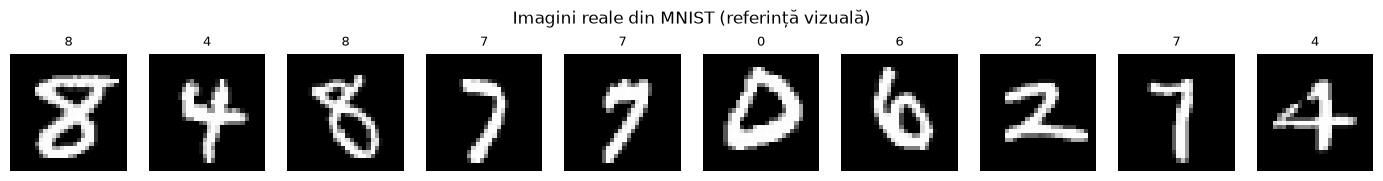

In [8]:
def arata_imagini_reale(n=10):
    idx = np.random.choice(X.shape[0], n, replace=False)
    imgs = (X[idx].reshape(-1, 28, 28) + 1) / 2.0   # revenim în [0, 1] doar pentru afișare
    fig, axes = plt.subplots(1, n, figsize=(1.4 * n, 1.8))
    for ax, img, lab in zip(axes, imgs, y_all[idx]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(str(lab), fontsize=9)
        ax.axis("off")
    fig.suptitle("Imagini reale din MNIST (referință vizuală)")
    plt.tight_layout()
    plt.show()

arata_imagini_reale(10)

In [9]:
IMAGE_SIZE   = 28 * 28     # 784 - dimensiunea vectorului imagine
LATENT_DIM   = 100         # dimensiunea spațiului latent (vectorul de zgomot)
BATCH_SIZE   = 128
EPOCHS       = 30          # 20-30 este suficient pentru cifre recognoscibile
LR_G         = 2e-4        # learning rate Generator
LR_D         = 2e-4        # learning rate Discriminator
BETA_1       = 0.5         # moment redus - recomandarea standard pentru GAN-uri
SAVE_EVERY   = 5           # la câte epoch-uri salvăm o "fotografie" a evoluției
N_PREVIEW    = 25          # câte imagini generăm în grila de vizualizare

steps_per_epoch = X.shape[0] // BATCH_SIZE
print(f"{steps_per_epoch} pași/epoch  ->  {steps_per_epoch * EPOCHS} actualizări în total")

546 pași/epoch  ->  16380 actualizări în total


In [10]:
def leaky_relu(slope=0.2):
    """
    Keras 3 a redenumit parametrul `alpha` în `negative_slope`.
    Funcția asigură compatibilitatea cu ambele generații de Keras.
    """
    try:
        return layers.LeakyReLU(negative_slope=slope)
    except TypeError:
        return layers.LeakyReLU(alpha=slope)


def build_generator(latent_dim=LATENT_DIM, out_dim=IMAGE_SIZE):
    model = keras.Sequential(
        [
            keras.Input(shape=(latent_dim,)),
            layers.Dense(256), leaky_relu(0.2),
            layers.Dense(512), leaky_relu(0.2),
            layers.Dense(1024), leaky_relu(0.2),
            layers.Dense(out_dim, activation="tanh"),
        ],
        name="generator",
    )
    return model


generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def build_discriminator(in_dim=IMAGE_SIZE):
    model = keras.Sequential(
        [
            keras.Input(shape=(in_dim,)),
            layers.Dense(512), leaky_relu(0.2),
            layers.Dropout(0.3),
            layers.Dense(256), leaky_relu(0.2),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="discriminator",
    )
    return model


discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_D, beta_1=BETA_1),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
print("Discriminator compilat.")

Discriminator compilat.


In [13]:
# Modelul combinat: z -> Generator -> imagine falsă -> Discriminator -> probabilitate
gan_input  = keras.Input(shape=(LATENT_DIM,), name="z")
fake_image = generator(gan_input)

# Înghețăm Discriminatorul ÎNAINTE de a compila modelul combinat:
# în modelul GAN vrem să se actualizeze DOAR ponderile Generatorului.
discriminator.trainable = False
gan_output = discriminator(fake_image)

gan = keras.Model(gan_input, gan_output, name="gan")
gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_G, beta_1=BETA_1),
    loss="binary_crossentropy",
)

# Îl dezghețăm la loc: în bucla de antrenare comutăm explicit flag-ul înainte de fiecare apel.
discriminator.trainable = True

gan.summary()

Model: "gan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z (InputLayer)                  │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator (Sequential)          │ (None, 784)            │     1,486,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Sequential)      │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,857 (7.71 MB)

 Trainable params: 2,019,857 (7.71 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Zgomot FIX: același input pentru Generator la fiecare "fotografie" a evoluției.
fixed_noise = np.random.normal(0, 1, (N_PREVIEW, LATENT_DIM)).astype("float32")


def unpack_metrics(out):
    """
    `train_on_batch` returnează un scalar, o listă sau un dict, în funcție de
    versiunea Keras și de metricile compilate. Normalizăm la [loss, metric].
    """
    if isinstance(out, dict):
        vals = list(out.values())
    elif isinstance(out, (list, tuple, np.ndarray)):
        vals = list(np.ravel(out))
    else:
        vals = [out]
    vals = [float(v) for v in vals]
    if len(vals) == 1:
        vals.append(float("nan"))
    return vals[0], vals[1]


def make_grid(vectors, rows=5, cols=5):
    """Transformă vectori de 784 valori în [-1,1] într-o singură imagine-mozaic rows x cols."""
    imgs = (np.asarray(vectors).reshape(-1, 28, 28) + 1.0) / 2.0
    imgs = np.clip(imgs, 0.0, 1.0)
    grid = np.zeros((rows * 28, cols * 28), dtype="float32")
    for k in range(min(rows * cols, imgs.shape[0])):
        r, c = divmod(k, cols)
        grid[r * 28:(r + 1) * 28, c * 28:(c + 1) * 28] = imgs[k]
    return grid


def preview_fixed(epoch_label, show=True):
    """Generează imagini din zgomotul FIX și returnează mozaicul 5x5."""
    gen = generator(fixed_noise, training=False).numpy()
    grid = make_grid(gen, 5, 5)
    if show:
        plt.figure(figsize=(4, 4))
        plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
        plt.title(f"Epoch {epoch_label}")
        plt.axis("off")
        plt.show()
    return grid

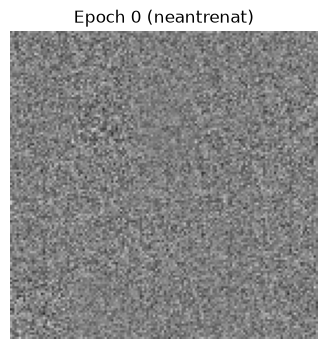

Epoch 1/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   1/30 | D loss = 0.5738 | D acc =  63.6% | G loss = 0.9574 |   25.7s


Epoch 2/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   2/30 | D loss = 0.5834 | D acc =  68.4% | G loss = 1.1352 |   62.2s


Epoch 3/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   3/30 | D loss = 0.5822 | D acc =  69.3% | G loss = 1.1795 |  108.6s


Epoch 4/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   4/30 | D loss = 0.5531 | D acc =  72.0% | G loss = 1.3257 |  147.8s


Epoch 5/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   5/30 | D loss = 0.5220 | D acc =  74.8% | G loss = 1.4277 |  169.5s


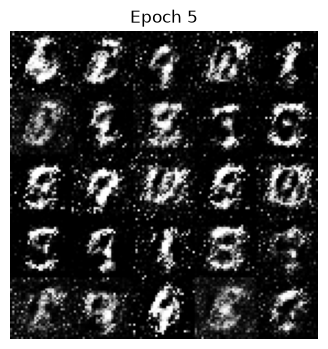

Epoch 6/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   6/30 | D loss = 0.5416 | D acc =  72.7% | G loss = 1.3466 |  200.3s


Epoch 7/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   7/30 | D loss = 0.5989 | D acc =  67.4% | G loss = 1.1298 |  246.3s


Epoch 8/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   8/30 | D loss = 0.6349 | D acc =  63.5% | G loss = 0.9890 |  291.9s


Epoch 9/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch   9/30 | D loss = 0.6391 | D acc =  63.1% | G loss = 0.9820 |  336.7s


Epoch 10/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  10/30 | D loss = 0.6578 | D acc =  60.3% | G loss = 0.9130 |  360.3s


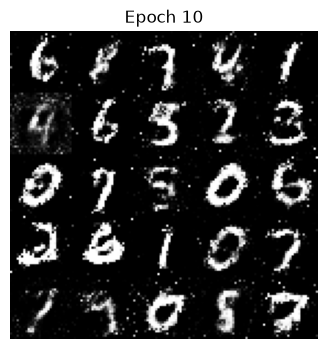

Epoch 11/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  11/30 | D loss = 0.6602 | D acc =  60.1% | G loss = 0.8898 |  383.9s


Epoch 12/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  12/30 | D loss = 0.6615 | D acc =  59.9% | G loss = 0.8849 |  425.1s


Epoch 13/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  13/30 | D loss = 0.6630 | D acc =  59.8% | G loss = 0.8731 |  468.9s


Epoch 14/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  14/30 | D loss = 0.6645 | D acc =  59.5% | G loss = 0.8702 |  499.6s


Epoch 15/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  15/30 | D loss = 0.6671 | D acc =  59.1% | G loss = 0.8561 |  541.7s


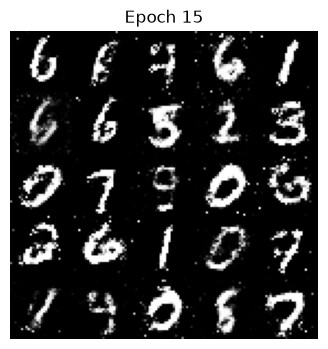

Epoch 16/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  16/30 | D loss = 0.6693 | D acc =  58.5% | G loss = 0.8520 |  574.2s


Epoch 17/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  17/30 | D loss = 0.6733 | D acc =  57.9% | G loss = 0.8398 |  618.4s


Epoch 18/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  18/30 | D loss = 0.6742 | D acc =  57.7% | G loss = 0.8303 |  662.7s


Epoch 19/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  19/30 | D loss = 0.6776 | D acc =  57.1% | G loss = 0.8196 |  706.5s


Epoch 20/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  20/30 | D loss = 0.6794 | D acc =  56.7% | G loss = 0.8160 |  745.3s


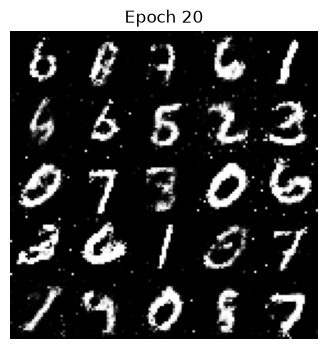

Epoch 21/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  21/30 | D loss = 0.6806 | D acc =  56.3% | G loss = 0.8058 |  774.0s


Epoch 22/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  22/30 | D loss = 0.6815 | D acc =  56.2% | G loss = 0.8014 |  820.9s


Epoch 23/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  23/30 | D loss = 0.6815 | D acc =  56.2% | G loss = 0.7968 |  868.3s


Epoch 24/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  24/30 | D loss = 0.6823 | D acc =  55.9% | G loss = 0.7941 |  915.3s


Epoch 25/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  25/30 | D loss = 0.6823 | D acc =  55.8% | G loss = 0.7914 |  960.5s


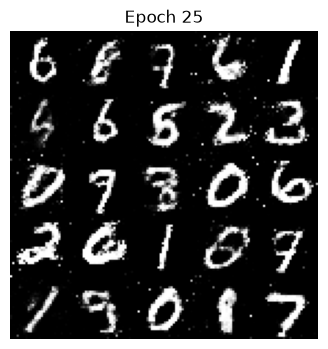

Epoch 26/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  26/30 | D loss = 0.6828 | D acc =  55.9% | G loss = 0.7879 |  995.7s


Epoch 27/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  27/30 | D loss = 0.6835 | D acc =  55.5% | G loss = 0.7862 | 1040.6s


Epoch 28/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  28/30 | D loss = 0.6839 | D acc =  55.4% | G loss = 0.7812 | 1085.9s


Epoch 29/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  29/30 | D loss = 0.6838 | D acc =  55.6% | G loss = 0.7806 | 1131.5s


Epoch 30/30:   0%|          | 0/546 [00:00<?, ?it/s]

Epoch  30/30 | D loss = 0.6833 | D acc =  55.6% | G loss = 0.7802 | 1178.4s


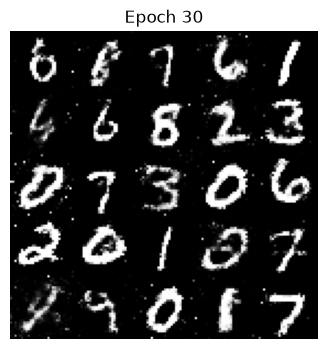


Antrenare terminată în 19.6 minute.


In [16]:
# Etichete constante, reutilizate la fiecare pas
y_real = np.ones((BATCH_SIZE, 1), dtype="float32")
y_fake = np.zeros((BATCH_SIZE, 1), dtype="float32")

history   = {"d_loss": [], "d_acc": [], "g_loss": []}
snapshots = []   # listă de (eticheta_epoch, mozaic 5x5)

# "Fotografia" de la epoch 0 = Generator neantrenat (zgomot pur)
snapshots.append(("0 (neantrenat)", preview_fixed("0 (neantrenat)", show=True)))

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    perm = np.random.permutation(X.shape[0])   # amestecăm datele la fiecare epoch
    d_losses, d_accs, g_losses = [], [], []

    for step in tqdm(range(steps_per_epoch), desc=f"Epoch {epoch}/{EPOCHS}", leave=False):

        # ---------- 1) Antrenarea DISCRIMINATORULUI ----------
        idx = perm[step * BATCH_SIZE:(step + 1) * BATCH_SIZE]
        real_imgs = X[idx]

        noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM)).astype("float32")
        # apelul direct al modelului e mult mai rapid decât .predict() într-o buclă
        fake_imgs = generator(noise, training=False).numpy()

        discriminator.trainable = True

        dl_r, da_r = unpack_metrics(discriminator.train_on_batch(real_imgs, y_real))
        discriminator.reset_metrics()          # metricile sunt cumulative în Keras 3
        dl_f, da_f = unpack_metrics(discriminator.train_on_batch(fake_imgs, y_fake))
        discriminator.reset_metrics()

        d_loss = 0.5 * (dl_r + dl_f)
        d_acc  = 0.5 * (da_r + da_f)

        # ---------- 2) Antrenarea GENERATORULUI (prin modelul GAN) ----------
        discriminator.trainable = False        # D înghețat: se actualizează doar G

        noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM)).astype("float32")
        g_loss, _ = unpack_metrics(gan.train_on_batch(noise, y_real))  # etichetă mincinoasă = 1
        gan.reset_metrics()

        d_losses.append(d_loss)
        d_accs.append(d_acc)
        g_losses.append(g_loss)

    history["d_loss"].append(float(np.mean(d_losses)))
    history["d_acc"].append(float(np.mean(d_accs)))
    history["g_loss"].append(float(np.mean(g_losses)))

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"D loss = {history['d_loss'][-1]:.4f} | "
          f"D acc = {history['d_acc'][-1]*100:5.1f}% | "
          f"G loss = {history['g_loss'][-1]:.4f} | "
          f"{time.time()-t0:6.1f}s")

    if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
        snapshots.append((str(epoch), preview_fixed(epoch, show=True)))

print(f"\nAntrenare terminată în {(time.time()-t0)/60:.1f} minute.")

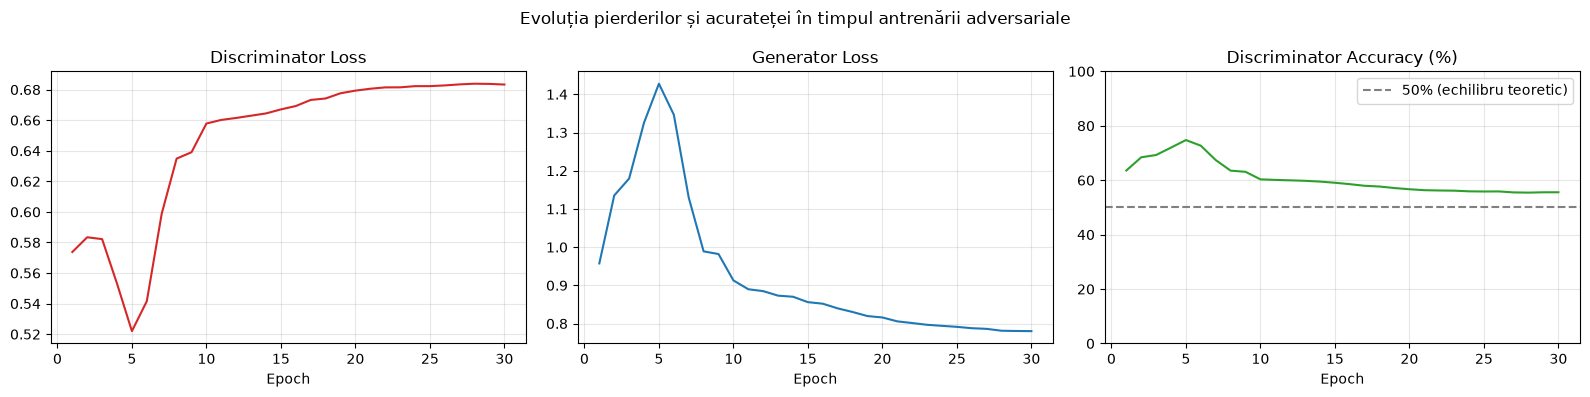

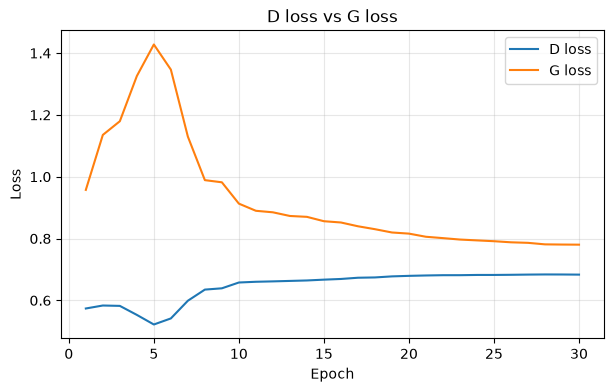

In [17]:
ep = np.arange(1, len(history["d_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep, history["d_loss"], color="tab:red")
axes[0].set_title("Discriminator Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=.3)

axes[1].plot(ep, history["g_loss"], color="tab:blue")
axes[1].set_title("Generator Loss"); axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=.3)

axes[2].plot(ep, np.array(history["d_acc"]) * 100, color="tab:green")
axes[2].axhline(50, ls="--", c="gray", label="50% (echilibru teoretic)")
axes[2].set_title("Discriminator Accuracy (%)"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 100); axes[2].legend(); axes[2].grid(alpha=.3)

plt.suptitle("Evoluția pierderilor și acurateței în timpul antrenării adversariale")
plt.tight_layout()
plt.show()

# Suprapunerea celor două pierderi - arată cel mai bine competiția
plt.figure(figsize=(7, 4))
plt.plot(ep, history["d_loss"], label="D loss")
plt.plot(ep, history["g_loss"], label="G loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=.3)
plt.title("D loss vs G loss")
plt.show()

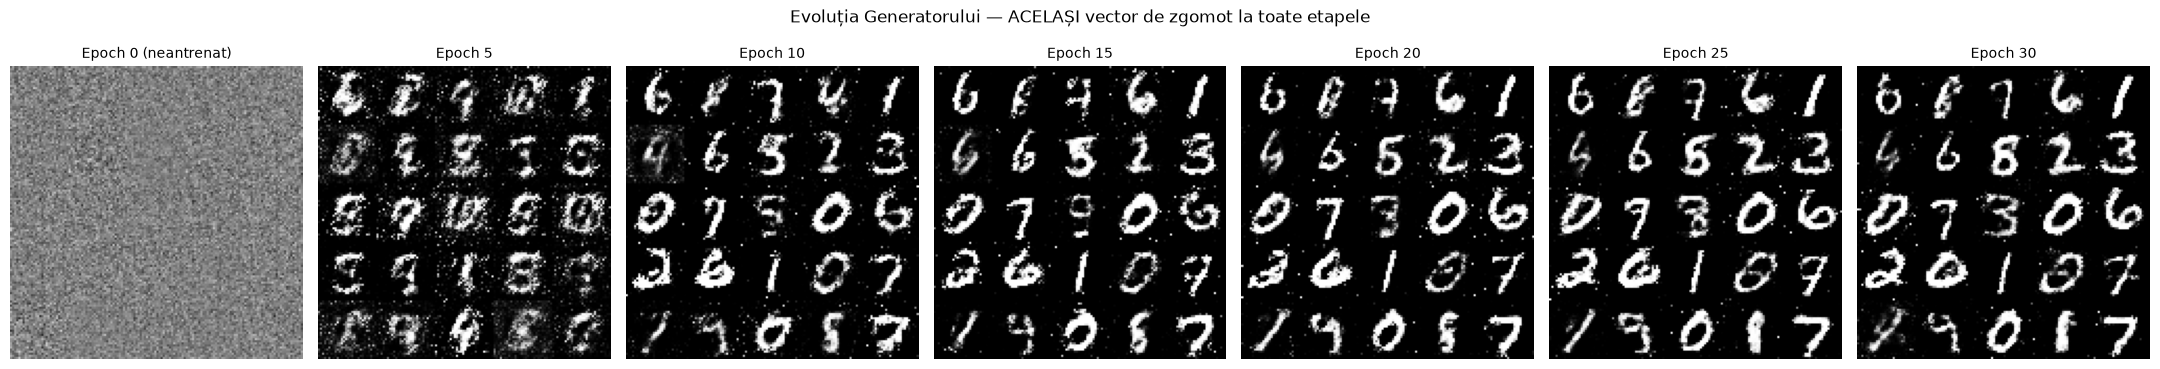

In [18]:
n = len(snapshots)
fig, axes = plt.subplots(1, n, figsize=(3.1 * n, 3.6))
if n == 1:
    axes = [axes]
for ax, (label, grid) in zip(axes, snapshots):
    ax.imshow(grid, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Epoch {label}", fontsize=10)
    ax.axis("off")
fig.suptitle("Evoluția Generatorului — ACELAȘI vector de zgomot la toate etapele", y=1.02)
plt.tight_layout()
plt.show()

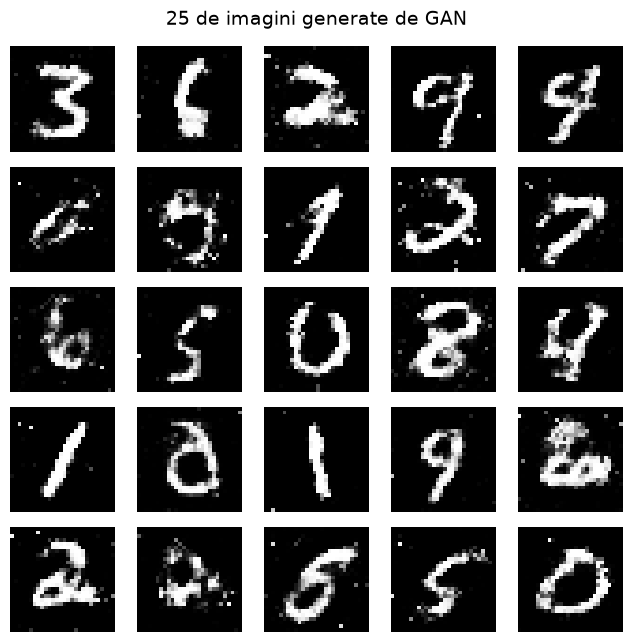

In [19]:
noise_final = np.random.normal(0, 1, (25, LATENT_DIM)).astype("float32")
gen_final   = generator(noise_final, training=False).numpy()

# [-1, 1] -> [0, 1] și 784 -> 28x28
imgs_final = np.clip((gen_final.reshape(-1, 28, 28) + 1.0) / 2.0, 0.0, 1.0)

fig, axes = plt.subplots(5, 5, figsize=(6.5, 6.5))
for ax, img in zip(axes.ravel(), imgs_final):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("25 de imagini generate de GAN", fontsize=14)
plt.tight_layout()
plt.show()

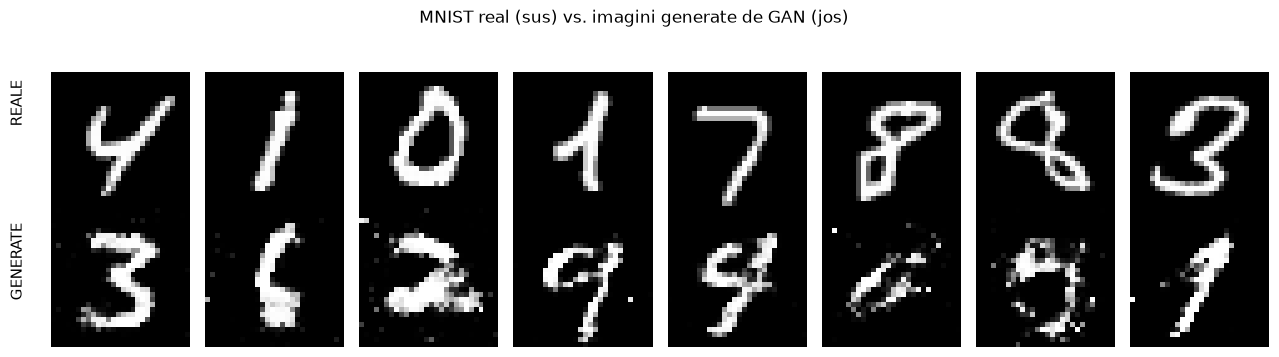

In [20]:
idx = np.random.choice(X.shape[0], 8, replace=False)
reale    = np.clip((X[idx].reshape(-1, 28, 28) + 1) / 2, 0, 1)
generate = imgs_final[:8]

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for j in range(8):
    axes[0, j].imshow(reale[j],    cmap="gray", vmin=0, vmax=1); axes[0, j].axis("off")
    axes[1, j].imshow(generate[j], cmap="gray", vmin=0, vmax=1); axes[1, j].axis("off")
axes[0, 0].set_ylabel("REAL");  axes[1, 0].set_ylabel("GENERAT")
fig.text(0.02, 0.72, "REALE",    rotation=90, va="center", fontsize=11)
fig.text(0.02, 0.28, "GENERATE", rotation=90, va="center", fontsize=11)
plt.suptitle("MNIST real (sus) vs. imagini generate de GAN (jos)")
plt.tight_layout(rect=[0.04, 0, 1, 0.94])
plt.show()

In [21]:
generator.save("generator_mnist_gan.keras")
discriminator.save("discriminator_mnist_gan.keras")
print("Modele salvate.")

Modele salvate.
